Personal introduction: Across the world, college students play variations of the game Cabo. Cabo is a hidden information card game where players rely on memorization, quick reflexes, and strategy to gain advantage and beat their opponents. Through this project I am interested in developing optimal strategies, determining the true benefit of a lucky hand, and most importantly creating for myself a worthy opponent (haha, you think i'm joking).

First, a couple notes on methodology. Cabo is a game that rewards quick reaction. However, automated opponents often can respond instantly and therefore simultaneously. As a result, tie-breaks in reaction will be resolved through random chance, which would annoy most human players, however, may prove to be another exciting tuning metric in decision making.

Random_Opponent: As the name suggests, "Random_Opponent" randomly calls Cabo 20% of the time. Additionally, "Random_Opponent" discards every card it picks up and does not use power cards. 

In [16]:
import glob
import pandas as pd

files = glob.glob("../backend/app/game_logs/random_opponent/*.jsonl")
print(f"{len(files)} game files found")

dfs = [pd.read_json(f, lines=True) for f in files] #each line becomes a df
events = pd.concat(dfs, ignore_index=True) #stacks the indvidual df into one combined df

1000 game files found


Q1: Out of 1000 games, what is the win rate distribution between the players?

Text(0, 0.5, 'Number of wins')

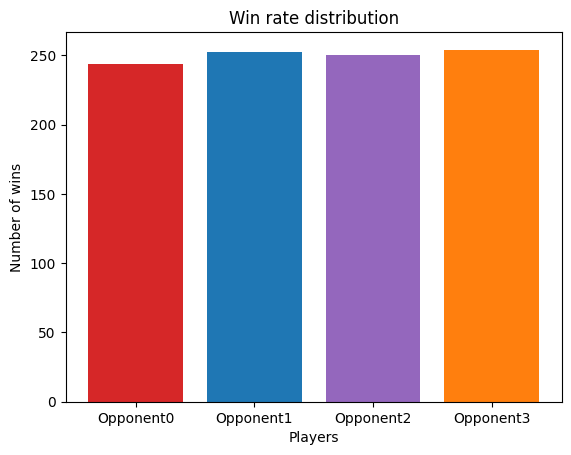

In [17]:

import matplotlib.pyplot as plt
final_winners = events[events.event_type == "final_winner"]

wins = []
players = ["Opponent0", "Opponent1", "Opponent2", "Opponent3" ]
for player in players:
    wins.append(final_winners[final_winners.player == player].shape[0])

#can also be done finalwinners.groupby("players").size()
bar_colors = ['tab:red', 'tab:blue', 'tab:purple', 'tab:orange']
plt.bar(players, wins, color = bar_colors)
plt.title("Win rate distribution")
plt.xlabel("Players")
plt.ylabel("Number of wins")

Interestingly, Opponent 0 saw the lowest number of wins, potentially because Opponent 0 played first everytime. Perhaps playing first in this game creates a disadvantage for the player (with this strategy).

Q2: How long did each game last?

In [18]:
events.head()

,game_id,timestamp,event_type,seed,player,card2_value,card2_suit,card3_value,card3_suit,drawn_card_value,drawn_card_suit,discarded_card_value,discarded_card_suit
0,004c614c-0e92-429c-b59b-1d07e785ebea,2026-07-16 02:43:22.181254864,game_start,1.428951e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,004c614c-0e92-429c-b59b-1d07e785ebea,2026-07-16 02:43:22.181417227,initial_reveal,NaN,Opponent0,10.0,Spade,4.0,Club,NaN,NaN,NaN,NaN
2,004c614c-0e92-429c-b59b-1d07e785ebea,2026-07-16 02:43:22.181449175,initial_reveal,NaN,Opponent1,5.0,Diamond,5.0,Club,NaN,NaN,NaN,NaN
3,004c614c-0e92-429c-b59b-1d07e785ebea,2026-07-16 02:43:22.181777477,initial_reveal,NaN,Opponent2,3.0,Diamond,6.0,Club,NaN,NaN,NaN,NaN
4,004c614c-0e92-429c-b59b-1d07e785ebea,2026-07-16 02:43:22.181804180,initial_reveal,NaN,Opponent3,7.0,Diamond,6.0,Heart,NaN,NaN,NaN,NaN


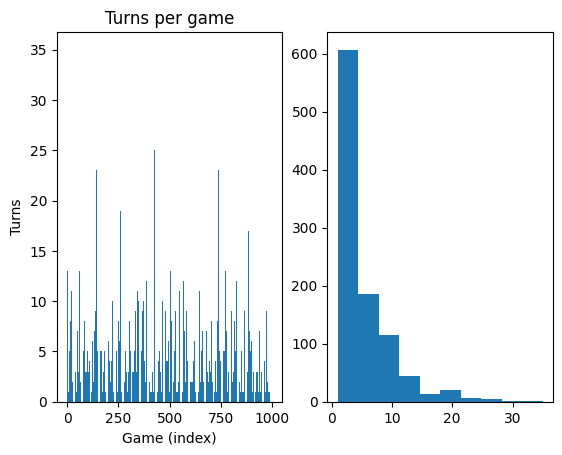

In [19]:
game_lengths = events[events.event_type == "curren_player_turn"].groupby("game_id").size() #spelling error when collecting data

plt.subplot(1,2,1)
plt.bar(range(len(game_lengths)), game_lengths.values)
plt.xlabel("Game (index)")
plt.ylabel("Turns")
plt.title("Turns per game")

plt.subplot(1,2,2)
plt.hist(game_lengths, bins = 10)
plt.show()